In [1]:
import os
import numpy as np
import kmapper as km
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import cluster, preprocessing, metrics, decomposition, manifold, ensemble

Here is the naming convention:
- B = Resistant line
- I = Susceptible line 1
- Z = Susceptible line 2
- M = Mock
- A = Bacterial inoculation
- 24 = RNA collected 24 hours after infection

Thus,
- BA24 = Resistant line, Bacterial inoculation, RNA collected 24 hours after infection
- IM24 = Susceptible line 1, Mock, RNA collected 24 hours after infection

TPM is very similar to RPKM and FPKM. The only difference is the order of operations. Here’s how you calculate TPM:

1. Divide the read counts by the length of each gene in kilobases. This gives you reads per kilobase (RPK).
1. Count up all the RPK values in a sample and divide this number by 1,000,000. This is your “per million” scaling factor.
1. Divide the RPK values by the “per million” scaling factor. This gives you TPM.

[Source](https://www.rna-seqblog.com/rpkm-fpkm-and-tpm-clearly-explained/)

In [2]:
fs = 12
lines = ['BA24_1','BA24_2','BM24_1','BM24_2','IA24_1','IA24_2','IM24_1','IM24_2','ZA24_1','ZA24_2','ZM24_1','ZM24_2']
filename = os.pardir + os.sep + 'raw' + os.sep + 'readCounts_Xa7_msu_v7.csv'
data = pd.read_csv(filename).set_index('Geneid')

rpk = data[lines].div(data['Length'], axis='index')
raw_tpm = rpk.div(rpk.sum(axis=0)/1e6, axis='columns')
raw_tpm = raw_tpm[ raw_tpm.std(axis=1) > 0 ]

tpm = raw_tpm.loc[ (raw_tpm.sum(axis=1) > raw_tpm.shape[1]) ]
std = tpm.std(axis=1)
mean = tpm.mean(axis=1)

varratio = std/mean
logvarratio = np.log10(varratio)

alpha = 0.01
mini, maxi = np.quantile(logvarratio, [alpha, 1-alpha])
chopped_logvr = logvarratio.copy()
chopped_logvr[chopped_logvr < mini] = mini
chopped_logvr[chopped_logvr > maxi] = maxi

print(data.shape, tpm.shape, sep='\t')

tpm.head()

(55986, 17)	(20117, 12)


,BA24_1,BA24_2,BM24_1,BM24_2,IA24_1,IA24_2,IM24_1,IM24_2,ZA24_1,ZA24_2,ZM24_1,ZM24_2
Geneid,,,,,,,,,,,,
LOC_Os01g01010,23.133621,22.533723,36.365026,20.774988,24.241255,19.080527,26.835956,27.504311,21.648054,17.114662,29.874780,26.511374
LOC_Os01g01030,1.441114,1.193850,1.692808,1.596698,2.288079,2.017914,1.373798,2.779524,1.463244,2.347877,2.583877,3.091158
LOC_Os01g01040,19.958814,13.469881,23.734983,20.503570,19.652930,19.996415,19.333245,21.402004,17.847978,17.359653,18.974958,19.536692
LOC_Os01g01050,19.626632,18.963796,32.713350,26.421081,21.307651,20.433110,23.974987,25.739951,20.373498,15.322905,26.671646,26.543966
LOC_Os01g01060,185.862879,141.570981,134.388872,129.749051,144.269360,215.770041,132.849454,102.662829,186.940809,203.003702,114.648839,112.747784


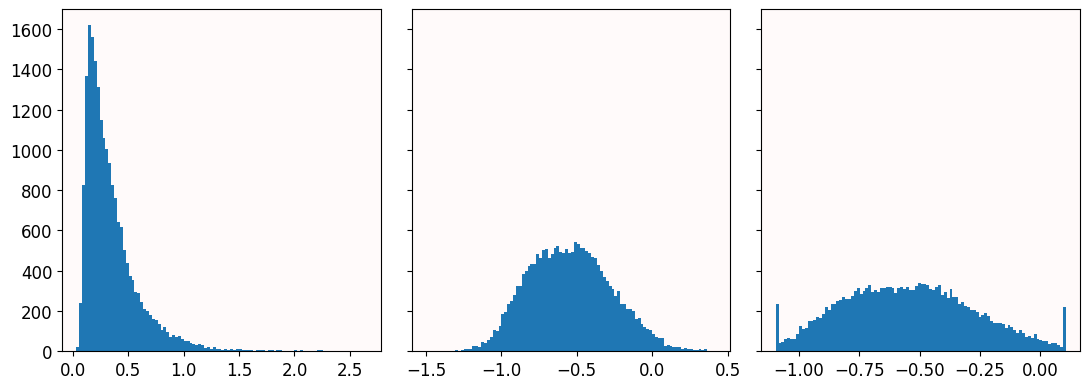

In [112]:
fig, ax = plt.subplots(1,3,figsize=(11,4), sharey=True)

ax[0].hist(varratio, bins=100);
ax[1].hist(logvarratio, bins=100);
ax[2].hist(chopped_logvr, bins=100);

for a in ax.ravel():
    a.set_facecolor('snow')
    a.tick_params(labelsize=fs)

fig.tight_layout()

In [93]:
scaler = preprocessing.StandardScaler(copy=True, with_std=True, with_mean=True).fit(tpm)
df = scaler.transform(tpm)
print(df.shape)

# Let's reduce our data to just 2 dimensions
PCA = decomposition.PCA(n_components=2, random_state=42, svd_solver='full').fit(df)
print('Considering the first', PCA.n_components,'PCs')

pca = PCA.transform(df).astype('float32')
explained_ratio = 100*PCA.explained_variance_ratio_
print(explained_ratio)
print('Total explained var:\t', np.sum(explained_ratio), np.sum(explained_ratio[:2]))

(20117, 12)
Considering the first 2 PCs
[89.64636688  5.99723908]
Total explained var:	 95.6436059622846 95.6436059622846


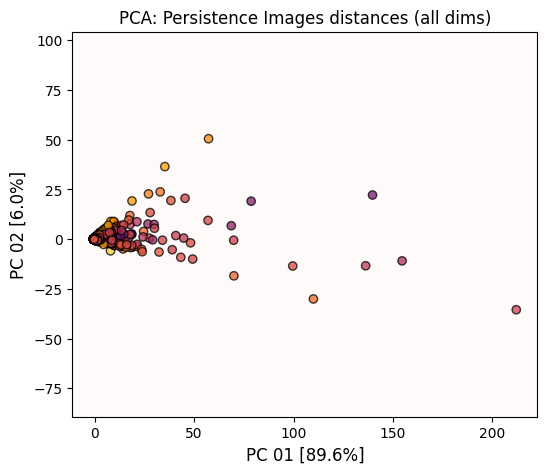

In [101]:
fig, ax = plt.subplots(1,1, figsize=(6,5))

ax.scatter(*pca.T, c=logvarratio, cmap='inferno', ec='k', marker='o', alpha=0.75)
ax.set_title('PCA: Persistence Images distances (all dims)', fontsize=fs)
ax.set_xlabel('PC 01 [{:.1f}%]'.format(explained_ratio[0]), fontsize=fs)
ax.set_ylabel('PC 02 [{:.1f}%]'.format(explained_ratio[1]), fontsize=fs);
ax.set_aspect('equal', 'datalim')
ax.set_facecolor('snow')
#n = 10; ax.set_xlim(-n,n); ax.set_ylim(-n/2,n/2);

In [177]:
# Initialize mapper object
mymapper = km.KeplerMapper(verbose=1)

# Define Nerve
nerve = km.GraphNerve(min_intersection=1)

# Define clustering algorithm
clusterer = cluster.DBSCAN(eps=0.5, metric='correlation')
#clusterer = cluster.KMeans(n_clusters=2,random_state=42)

KeplerMapper(verbose=1)


In [172]:
# Create a custom 1-D lens with Isolation Forest
model = ensemble.IsolationForest(random_state=42).fit(tpm.values)
lens1 = model.decision_function(tpm.values).reshape((tpm.shape[0], 1))

# Create another 1-D lens with L2-norm
mapper = km.KeplerMapper(verbose=0)
lens2 = mapper.project(tpm.values, projection="std")
#lens2 = preprocessing.minmax_scale(np.sqrt(np.sum(tpm.values**2, axis=1)))

In [198]:
lens2 = (tpm.max(axis=1) - tpm.min(axis=1))
a,b = np.sort(tpm.values, axis=1)[:, [1,-2]].T

lens2 = np.log10(b-a)

#lens2 = logvarratio
# Combine lenses pairwise to get a 2-D lens i.e. [Isolation Forest, L^2-Norm] lens
lens = np.c_[lens1, lens2]

In [199]:
cubes, overlap = 110, 40
cover = km.cover.Cover(n_cubes=cubes, perc_overlap=overlap/100.)

In [200]:
# Create mapper graph with nodes, edges and meta-information.
graph = mymapper.map(lens=lens,
                     X=tpm,
                     clusterer=clusterer,
                     cover=cover,
                     nerve=nerve,
                     precomputed=False,
                     remove_duplicate_nodes=True)

# Specify file to save html output
fpath = os.pardir + os.sep + 'outputs' + os.sep + f"Filter_Cubes_{cubes}_Overlap_{overlap}.html"
figtitle = f"#Cubes {cubes}, Overlap: {overlap/100.0}%"

_ = mymapper.visualize(graph,
                       path_html=fpath,
                       title=figtitle,
                       color_values=chopped_logvr,
                       colorscale=None,
                       color_function_name=["log10varratio"],
                       nbins = 10)
                       #include_searchbar=True)

Mapping on data shaped (20117, 12) using lens shaped (20117, 2)

Creating 12100 hypercubes.
No duplicate nodes found to remove.


Created 3066 edges and 954 nodes in 0:00:02.985717.
Wrote visualization to: ../outputs/Filter_Cubes_110_Overlap_40.html


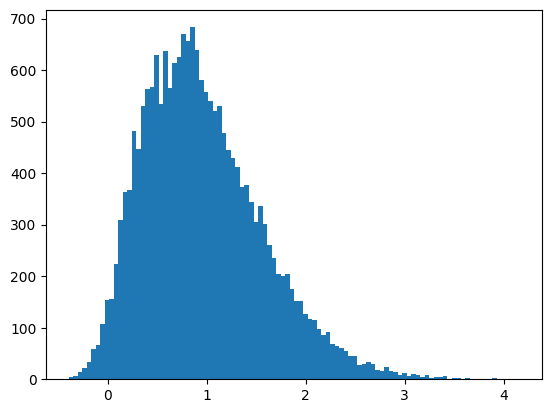

In [197]:
plt.hist(np.log10(b-a), bins=100);